# Olist E-Commerce Analysis

Exploratory data analysis of Olist, a Brazilian e-commerce platform. This notebook answers three key business questions using a real dataset of over 99,000 orders placed between 2016 and 2018.

## 1. Data Loading & Exploration

Loading and exploring the main orders dataset to understand its structure, data types, and data quality.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/olist_orders_dataset.csv")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
filas, n_columnas = df.shape
print(f'Hay {filas} filas y {n_columnas} columnas')

Hay 99441 filas y 8 columnas


In [3]:
nombres_columnas = list(df.columns)
print(f'Los nombres de las columnas son:\n {nombres_columnas}')

Los nombres de las columnas son:
 ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [5]:
df.value_counts("order_status")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
pedidos = df.shape[0]
entregados = df[df['order_status'] == 'delivered'].shape[0]
tasa_entrega = (entregados / pedidos) * 100
print(f'El porcentaje de pedidos entregados es: {tasa_entrega:.2f}%')

El porcentaje de pedidos entregados es: 97.02%


## 2. Revenue Analysis

Loading the order items dataset and calculating total revenue for delivered orders only. We then analyze how revenue evolved month by month between 2016 and 2018.

In [7]:
df_items = pd.read_csv("../data/olist_order_items_dataset.csv")
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
filas, n_columnas = df_items.shape
print(f'Hay {filas} filas y {n_columnas} columnas')

Hay 112650 filas y 7 columnas


In [9]:
df_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [10]:
total_precio_ventas = df_items['price'].sum()
print(f'El precio total de las ventas es: R$ {total_precio_ventas:,.2f}')

El precio total de las ventas es: R$ 13,591,643.70


In [11]:
df_merged = df.merge(df_items, on='order_id')
df_merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [12]:
filas, n_columnas = df_merged.shape
print(f'Hay {filas} filas y {n_columnas} columnas')

df_delivered = df_merged[df_merged['order_status'] == 'delivered'].copy()
filas, n_columnas = df_delivered.shape
print(f'Pedidos entregados: {filas} filas y {n_columnas} columnas')

Hay 112650 filas y 14 columnas
Pedidos entregados: 110197 filas y 14 columnas


In [13]:
total_precio_ventas_delivered = df_delivered['price'].sum()
print(f'Revenue total (solo entregados): R$ {total_precio_ventas_delivered:,.2f}')
print(f'Revenue no recuperado:           R$ {total_precio_ventas - total_precio_ventas_delivered:,.2f}')

Revenue total (solo entregados): R$ 13,221,498.11
Revenue no recuperado:           R$ 370,145.59


In [14]:
df_delivered['order_purchase_timestamp'] = pd.to_datetime(df_delivered['order_purchase_timestamp'])
df_delivered.info()

<class 'pandas.DataFrame'>
Index: 110197 entries, 0 to 112649
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  str           
 1   customer_id                    110197 non-null  str           
 2   order_status                   110197 non-null  str           
 3   order_purchase_timestamp       110197 non-null  datetime64[us]
 4   order_approved_at              110182 non-null  str           
 5   order_delivered_carrier_date   110195 non-null  str           
 6   order_delivered_customer_date  110189 non-null  str           
 7   order_estimated_delivery_date  110197 non-null  str           
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  str           
 10  seller_id                      110197 non-null  str           
 11  shipping_limit_d

In [15]:
df_delivered['mes'] = df_delivered['order_purchase_timestamp'].dt.to_period('M')
df_delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,mes
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02


In [16]:
revenue_mensual = df_delivered.groupby('mes')['price'].sum()
print(revenue_mensual)
print(f'\nEl pico mas alto del revenue fue en: {revenue_mensual.idxmax()} debido al Black Friday')

mes
2016-09       134.97
2016-10     40325.11
2016-12        10.90
2017-01    111798.36
2017-02    234223.40
2017-03    359198.85
2017-04    340669.68
2017-05    489338.25
2017-06    421923.37
2017-07    481604.52
2017-08    554699.70
2017-09    607399.67
2017-10    648247.65
2017-11    987765.37
2017-12    726033.19
2018-01    924645.00
2018-02    826437.13
2018-03    953356.25
2018-04    973534.09
2018-05    977544.69
2018-06    856077.86
2018-07    867953.46
2018-08    838576.64
Freq: M, Name: price, dtype: float64

El pico mas alto del revenue fue en: 2017-11 debido al Black Friday


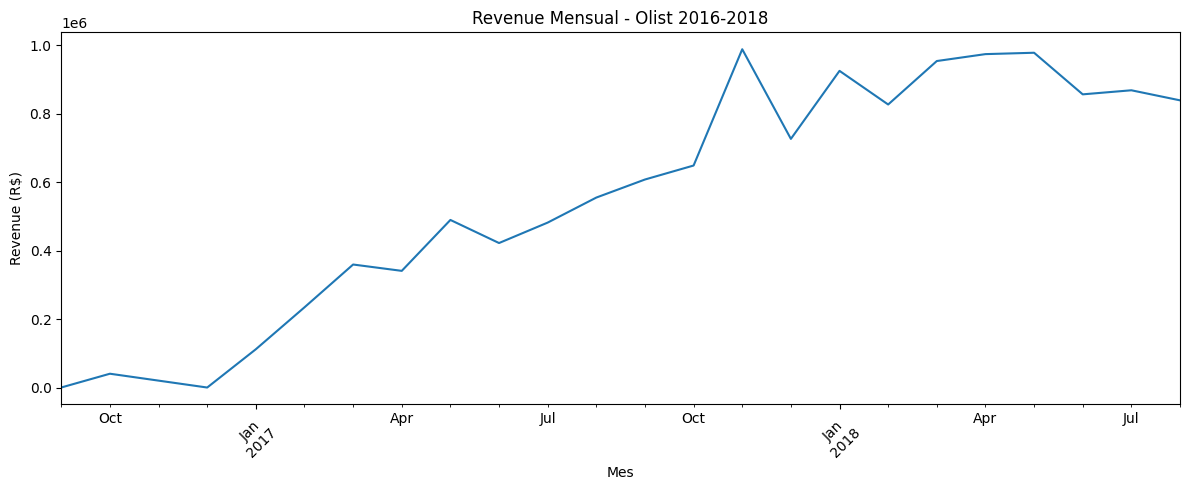

In [30]:
plt.figure(figsize=(12, 5))
revenue_mensual.plot()
plt.title('Revenue Mensual - Olist 2016-2018')
plt.xlabel('Mes')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Top Product Categories by Revenue

Loading the products dataset and joining it with delivered orders to identify which product categories generate the most revenue.

In [18]:
df_products = pd.read_csv("../data/olist_products_dataset.csv")
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [19]:
filas, n_columnas = df_products.shape
print(f'Hay {filas} filas y {n_columnas} columnas')

Hay 32951 filas y 9 columnas


In [20]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [21]:
df_full = df_products.merge(df_delivered, on='product_id')
print(f'Shape del merge: {df_full.shape}')

Shape del merge: (110197, 23)


In [22]:
revenue_categoria = df_full.groupby('product_category_name')['price'].sum()
top10_categorias = revenue_categoria.sort_values(ascending=False).head(10)
print(top10_categorias)

product_category_name
beleza_saude              1233131.72
relogios_presentes        1166176.98
cama_mesa_banho           1023434.76
esporte_lazer              954852.55
informatica_acessorios     888724.61
moveis_decoracao           711927.69
utilidades_domesticas      615628.69
cool_stuff                 610204.10
automotivo                 578966.65
brinquedos                 471286.48
Name: price, dtype: float64


In [23]:
df_traduccion = pd.read_csv("../data/product_category_name_translation.csv")
top10_df = top10_categorias.reset_index()
top10_translated = top10_df.merge(df_traduccion, on='product_category_name')
print(top10_translated)

    product_category_name       price product_category_name_english
0            beleza_saude  1233131.72                 health_beauty
1      relogios_presentes  1166176.98                 watches_gifts
2         cama_mesa_banho  1023434.76                bed_bath_table
3           esporte_lazer   954852.55                sports_leisure
4  informatica_acessorios   888724.61         computers_accessories
5        moveis_decoracao   711927.69               furniture_decor
6   utilidades_domesticas   615628.69                    housewares
7              cool_stuff   610204.10                    cool_stuff
8              automotivo   578966.65                          auto
9              brinquedos   471286.48                          toys


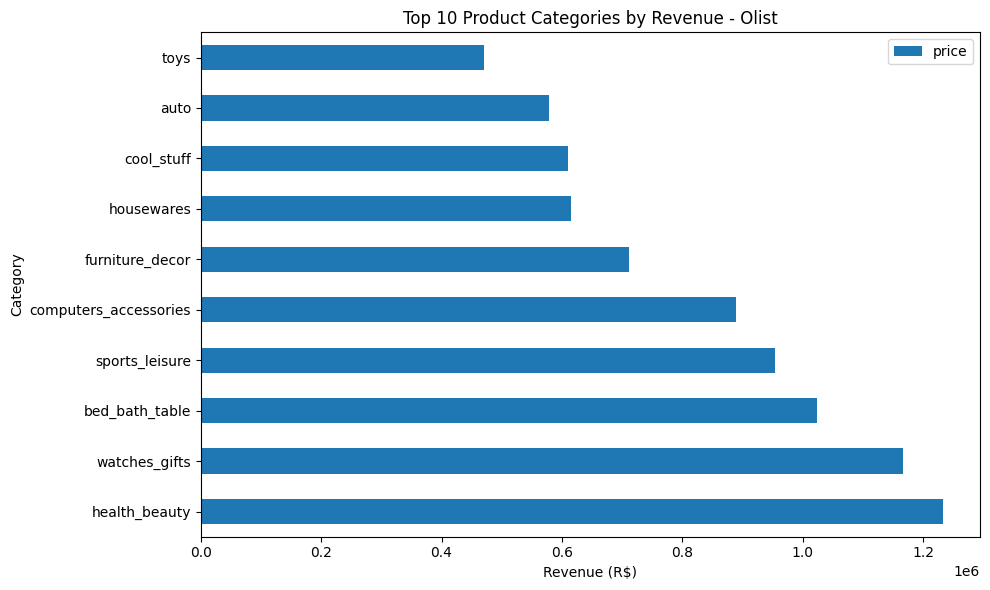

In [24]:
top10_translated.plot(kind='barh', x='product_category_name_english', y='price', figsize=(10, 6))
plt.title('Top 10 Product Categories by Revenue - Olist')
plt.xlabel('Revenue (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## 4. Revenue by State

Joining the customers dataset to analyze the geographic distribution of revenue across Brazilian states.

In [25]:
df_customers = pd.read_csv("../data/olist_customers_dataset.csv")
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [26]:
filas, n_columnas = df_customers.shape
print(f'Hay {filas} filas y {n_columnas} columnas')
df_customers.info()

Hay 99441 filas y 5 columnas
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [27]:
df_merged_customers = df_customers.merge(df_full, on='customer_id')
filas, n_columnas = df_merged_customers.shape
print(f'Hay {filas} filas y {n_columnas} columnas')

Hay 110197 filas y 27 columnas


In [28]:
revenue_customers = df_merged_customers.groupby('customer_state')['price'].sum()
revenue_customers = revenue_customers.sort_values(ascending=False).head(10)
print(revenue_customers)

customer_state
SP    5067633.16
RJ    1759651.13
MG    1552481.83
RS     728897.47
PR     666063.51
SC     507012.13
BA     493584.14
DF     296498.41
GO     282836.70
ES     268643.45
Name: price, dtype: float64


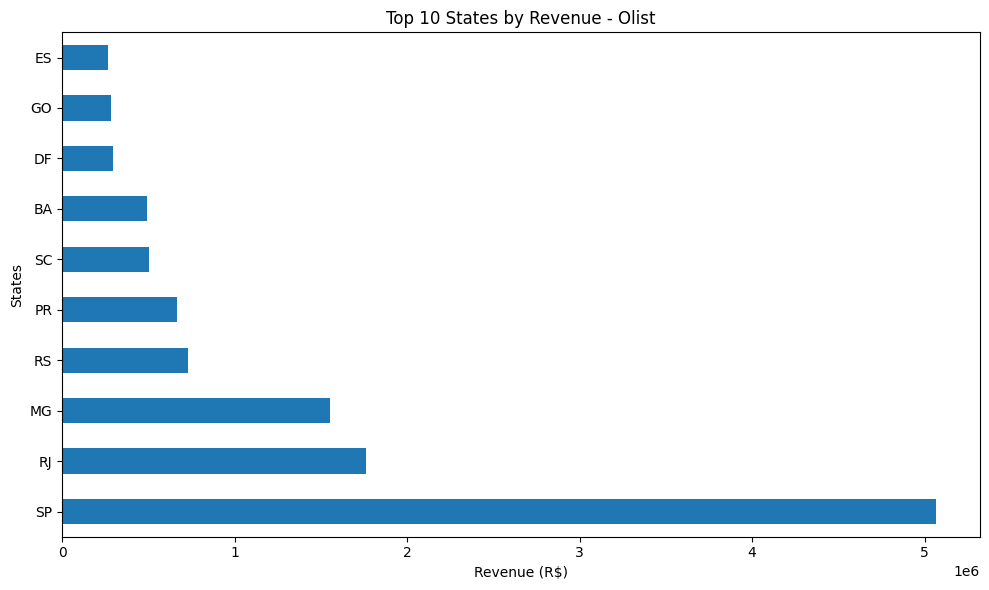

In [29]:
revenue_customers.plot(kind='barh', figsize=(10, 6))
plt.title('Top 10 States by Revenue - Olist')
plt.xlabel('Revenue (R$)')
plt.ylabel('States')
plt.tight_layout()
plt.show()

# Conclusions

- **97.02% delivery rate**: Olist successfully delivered 96,478 out of 99,441 orders. Undelivered orders represent R$ 370,145 in unrecovered revenue.
- **Black Friday peak**: November 2017 was the highest-revenue month (R$ 987,765), nearly doubling the average monthly revenue.
- **Top category**: Health & Beauty leads with R$ 1,233,131 in revenue, followed by Watches & Gifts and Bed, Bath & Table.
- **Geographic concentration**: São Paulo (SP) dominates with R$ 5,067,633 — almost 3x the revenue of second-place Rio de Janeiro (RJ).